In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [33]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_excel("filtered_election_requests.xlsx")

In [3]:
df.head()

,SR ID,Opened,Closed,Status,Department,Area,Sub-Area,Attached Solution (Topic),Attached Solution SLA Days,City,...,Council Member Name,Changed Date,# of Days Open,Within SLA Windows,SLA Yes,SLA No,Request Type,service,readiness_focus,topic
0,1202713438,05/29/2014 11:57:28 AM,05/29/2014 12:02:23 PM,Closed,BOE,Absentee,Military or Overseas,Questions regarding Absentee Ballots for Milit...,1,NaN,...,NaN,05/29/2014 04:02:24 PM,0,Yes,1,0,General Information,absentee military or overseas questions regard...,vote_by_mail,Military/overseas ballot
1,1122302648,10/31/2012 11:04:29 AM,10/31/2012 11:06:50 AM,Closed,BOE,Other,NaN,Early Voting 2014,1,NaN,...,NaN,10/31/2012 03:06:50 PM,0,Yes,1,0,General Information,other early voting 2014 general information,polling_place_information,Early voting
2,1203226216,06/02/2014 08:46:19 AM,06/02/2014 08:47:33 AM,Closed,BOE,Absentee,General,Absentee Ballot Questions,1,NaN,...,NaN,06/02/2014 12:47:35 PM,0,Yes,1,0,General Information,absentee general absentee ballot questions gen...,vote_by_mail,General vote-by-mail questions
3,1203226463,06/02/2014 08:52:59 AM,06/02/2014 08:58:53 AM,Closed,BOE,Absentee,Military or Overseas,Absentee Ballots Faxed or Mailed Federal Post ...,2,NaN,...,NaN,06/02/2014 12:58:54 PM,0,Yes,1,0,General Information,absentee military or overseas absentee ballots...,vote_by_mail,Military/overseas ballot
4,1122259887,10/31/2012 09:23:20 AM,10/31/2012 09:27:08 AM,Closed,BOE,Other,NaN,Early Voting 2014,1,NaN,...,NaN,10/31/2012 01:27:09 PM,0,Yes,1,0,General Information,other early voting 2014 general information,polling_place_information,Early voting


In [4]:
df.shape

(11654, 28)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11654 entries, 0 to 11653
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SR ID                       11654 non-null  int64  
 1   Opened                      11654 non-null  str    
 2   Closed                      11653 non-null  str    
 3   Status                      11654 non-null  str    
 4   Department                  11654 non-null  str    
 5   Area                        11635 non-null  str    
 6   Sub-Area                    6528 non-null   str    
 7   Attached Solution (Topic)   11654 non-null  str    
 8   Attached Solution SLA Days  11654 non-null  int64  
 9   City                        1208 non-null   str    
 10  State                       11651 non-null  str    
 11  Zip Code                    1211 non-null   float64
 12  Source                      11654 non-null  str    
 13  Election District           1175 non-null 

In [6]:
df.describe()

,SR ID,Attached Solution SLA Days,Zip Code,Election District,Congressional District,Council District,# of Days Open,SLA Yes,SLA No
count,1.165400e+04,11654.000000,1211.000000,1175.000000,1175.000000,1175.000000,11654.000000,11654.000000,11654.000000
mean,1.356501e+09,1.354213,20912.246078,8.502128,6.875745,3.099574,0.250815,0.992020,0.007980
std,1.515995e+08,0.478295,2308.704919,3.635869,1.664301,1.596779,5.781008,0.088978,0.088978
min,1.106495e+09,1.000000,1240.000000,1.000000,3.000000,1.000000,0.000000,0.000000,0.000000
25%,1.233452e+09,1.000000,20852.000000,5.000000,6.000000,1.000000,0.000000,1.000000,0.000000
50%,1.370282e+09,1.000000,20877.000000,8.000000,8.000000,3.000000,0.000000,1.000000,0.000000
75%,1.455718e+09,2.000000,20903.000000,13.000000,8.000000,4.000000,0.000000,1.000000,0.000000
max,1.624668e+09,2.000000,81236.000000,13.000000,8.000000,7.000000,336.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

SR ID                             0
Opened                            0
Closed                            1
Status                            0
Department                        0
Area                             19
Sub-Area                       5126
Attached Solution (Topic)         0
Attached Solution SLA Days        0
City                          10446
State                             3
Zip Code                      10443
Source                            0
Election District             10479
Maryland State District       10479
Congressional District        10479
Congressional Member          10479
Council District              10479
Council Member Name           10479
Changed Date                      0
# of Days Open                    0
Within SLA Windows                0
SLA Yes                           0
SLA No                            0
Request Type                      0
service                           0
readiness_focus                   0
topic                       

In [8]:
df["readiness_focus"].value_counts()

readiness_focus
vote_by_mail                 2952
other_boe                    2833
registration_status          2752
polling_place_information    2549
election_judge_support        446
candidate_support             122
Name: count, dtype: int64

In [9]:
registration = df[
    df["readiness_focus"] == "registration_status"
].copy()

registration.shape

(2752, 28)

In [10]:
registration["topic"].value_counts()

topic
General voter registration questions     718
Registration verification                579
Registering to vote                      458
Address or name change                   382
Eligibility/residency/re-registration    179
Voter notification card                  152
Record maintenance                       110
Party affiliation                         97
Registration deadline                     77
Name: count, dtype: int64

In [11]:
registration["slow_request"] = (
    registration["# of Days Open"] > 1
).astype(int)

registration["slow_request"].value_counts()

slow_request
0    2702
1      50
Name: count, dtype: int64

In [12]:
registration["slow_request"].value_counts(normalize=True)

slow_request
0    0.981831
1    0.018169
Name: proportion, dtype: float64

In [13]:
# Create month and day of week

registration["Opened"] = pd.to_datetime(
    registration["Opened"]
)

registration["month"] = registration["Opened"].dt.month
registration["day_of_week"] = registration["Opened"].dt.dayofweek 

registration["month_name"] = registration["Opened"].dt.month_name()

In [14]:
features = [
    "topic",
    "Source",
    "Request Type",
    "Area",
    "Sub-Area",
    "month",
    "day_of_week"
]

X = registration[features]
y = registration["slow_request"]

In [15]:
registration.groupby("topic")["slow_request"].mean().sort_values(
    ascending=False
)

topic
Record maintenance                       0.100000
Voter notification card                  0.078947
Address or name change                   0.060209
Eligibility/residency/re-registration    0.005587
General voter registration questions     0.002786
Registering to vote                      0.002183
Party affiliation                        0.000000
Registration deadline                    0.000000
Registration verification                0.000000
Name: slow_request, dtype: float64

In [16]:
topic_summary = registration.groupby("topic").agg(
    total_requests=("slow_request", "size"),
    slow_requests=("slow_request", "sum"),
    slow_rate=("slow_request", "mean")
)

topic_summary.sort_values("slow_rate", ascending=False)

,total_requests,slow_requests,slow_rate
topic,,,
Record maintenance,110,11,0.100000
Voter notification card,152,12,0.078947
Address or name change,382,23,0.060209
Eligibility/residency/re-registration,179,1,0.005587
General voter registration questions,718,2,0.002786
Registering to vote,458,1,0.002183
Party affiliation,97,0,0.000000
Registration deadline,77,0,0.000000
Registration verification,579,0,0.000000


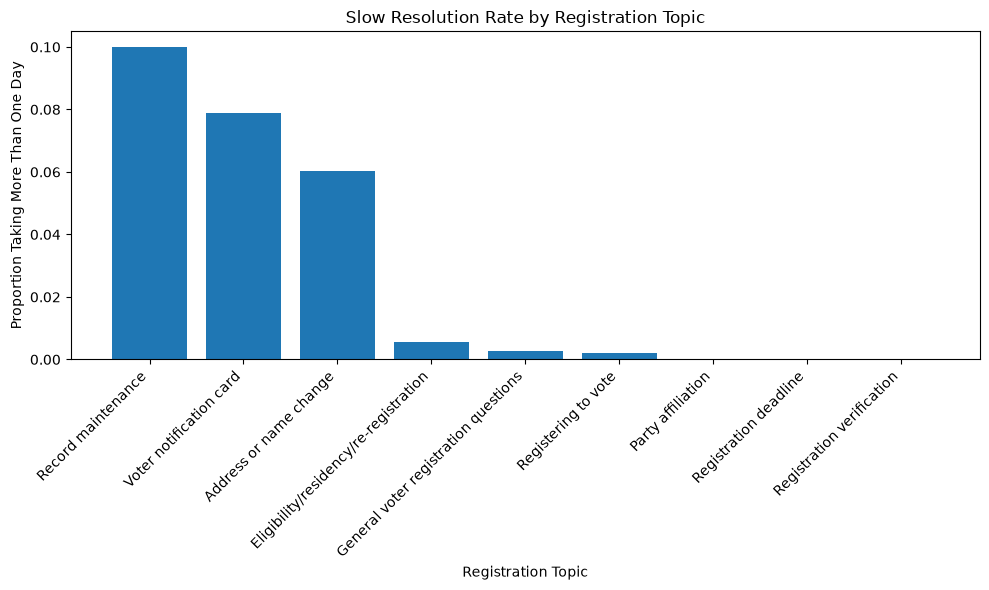

In [17]:
# Make visuals

topic_summary = topic_summary.sort_values("slow_rate", ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    topic_summary.index,
    topic_summary["slow_rate"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion Taking More Than One Day")
plt.xlabel("Registration Topic")
plt.title("Slow Resolution Rate by Registration Topic")

plt.tight_layout()
plt.show()

In [18]:
#Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
# Build baseline

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print("Baseline F1:",
      f1_score(y_test, baseline_predictions))

print("Baseline Precision:",
      precision_score(y_test, baseline_predictions, zero_division=0))

print("Baseline Recall:",
      recall_score(y_test, baseline_predictions, zero_division=0))

Baseline F1: 0.0
Baseline Precision: 0.0
Baseline Recall: 0.0


In [20]:
categorical_features = [
    "topic",
    "Source",
    "Request Type",
    "Area",
    "Sub-Area"
]

numeric_features = [
    "month",
    "day_of_week"
]

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [22]:
# Create model

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

In [23]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['topic','Source','Request Type',...,'Sub-Area','month','day_of_week']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

In [43]:
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1:", f1_score(y_test, predictions))

Accuracy: 0.956442831215971
Precision: 0.29411764705882354
Recall: 1.0
F1: 0.45454545454545453


In [44]:
print(confusion_matrix(y_test, predictions))

[[517  24]
 [  0  10]]


In [45]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1"],
)

In [46]:
print("Accuracy scores:", cv_results["test_accuracy"])
print("Precision scores:", cv_results["test_precision"])
print("Recall scores:", cv_results["test_recall"])
print("F1 scores:", cv_results["test_f1"])

Accuracy scores: [0.94736842 0.94736842 0.95272727 0.94545455 0.95090909]
Precision scores: [0.25641026 0.25641026 0.26470588 0.23684211 0.27027027]
Recall scores: [1.  1.  0.9 0.9 1. ]
F1 scores: [0.40816327 0.40816327 0.40909091 0.375      0.42553191]


In [47]:
print("\nAverage Accuracy:", cv_results["test_accuracy"].mean())
print("Average Precision:", cv_results["test_precision"].mean())
print("Average Recall:", cv_results["test_recall"].mean())
print("Average F1:", cv_results["test_f1"].mean())


Average Accuracy: 0.9487655502392345
Average Precision: 0.2569277541413764
Average Recall: 0.96
Average F1: 0.40518987091935427


In [48]:
print("\nF1 Standard Deviation:", cv_results["test_f1"].std())


F1 Standard Deviation: 0.01648106371781002


In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       541
           1       0.29      1.00      0.45        10

    accuracy                           0.96       551
   macro avg       0.65      0.98      0.72       551
weighted avg       0.99      0.96      0.97       551



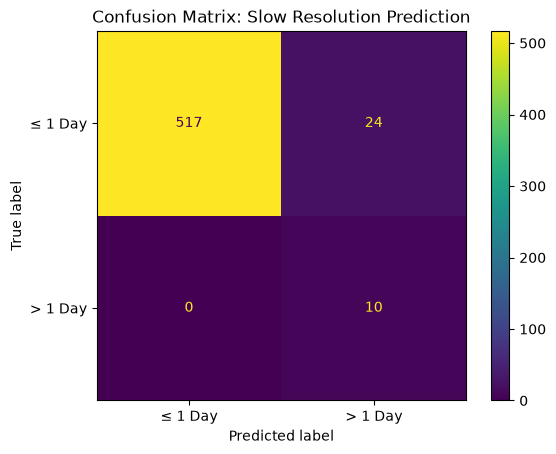

In [28]:
# Make Confusion Matrix

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["≤ 1 Day", "> 1 Day"]
)

disp.plot()
plt.title("Confusion Matrix: Slow Resolution Prediction")
plt.show()

In [29]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = model.named_steps[
    "classifier"
].coef_[0]

importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

importance["absolute_coefficient"] = (
    importance["coefficient"].abs()
)

importance = importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

importance.head(15)

,feature,coefficient,absolute_coefficient
13,categorical__Request Type_General Information,-3.492536,3.492536
15,categorical__Request Type_Service Request - Fu...,3.464700,3.464700
7,categorical__topic_Registration verification,-1.481995,1.481995
21,categorical__Sub-Area_nan,1.461593,1.461593
10,categorical__Source_Phone,-0.834381,0.834381
0,categorical__topic_Address or name change,0.826043,0.826043
18,categorical__Sub-Area_General,-0.802837,0.802837
3,categorical__topic_Party affiliation,-0.773932,0.773932
1,categorical__topic_Eligibility/residency/re-re...,0.738045,0.738045
12,categorical__Source_Web,0.735078,0.735078


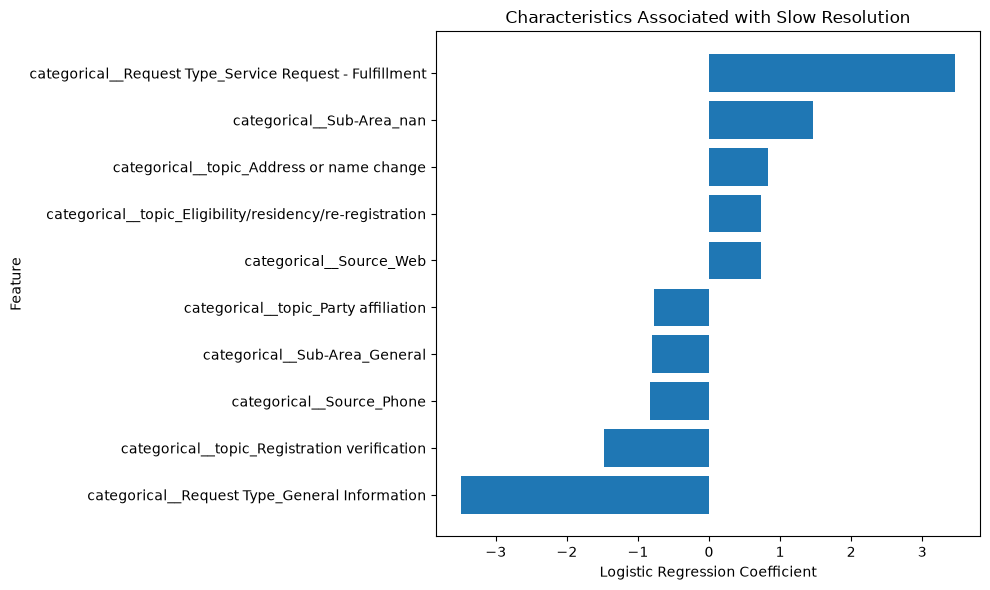

In [30]:
top_features = importance.head(10).sort_values(
    "coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Characteristics Associated with Slow Resolution")

plt.tight_layout()
plt.show()